In [18]:
import librosa
import soundfile as sf
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Download RAVDESS Dataset
#### RAVDESS = Ryerson Audio-Visual Database of Emotional Speech and Song

In [2]:
!pip install gdown
import gdown

# Download sample RAVDESS data
!wget -q --show-progress \
  "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
!unzip -q Audio_Speech_Actors_01-24.zip -d ravdess_data/

Audio_Speech_Actors 100%[===================>] 198.81M  19.5MB/s    in 11s     


RAVDESS Filename Convention:
Format: 03-01-06-01-02-01-12.wav

Position meanings:
1. Modality (03 = audio-only)
2. Vocal channel (01 = speech)
3. Emotion:
   01 = neutral
   02 = calm
   03 = happy
   04 = sad
   05 = angry
   06 = fearful
   07 = disgust
   08 = surprised
4. Emotional intensity (01=normal, 02=strong)
5. Statement (01, 02)
6. Repetition (01, 02)
7. Actor (01-24, odd=male, even=female)


In [3]:
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

observed_emotions = ['calm', 'happy', 'fearful', 'disgust']

print("🎭 Emotion Categories:")
for code, emotion in emotions.items():
    marker = "✅" if emotion in observed_emotions else "⬜"
    print(f"  {marker} Code {code}: {emotion}")


🎭 Emotion Categories:
  ⬜ Code 01: neutral
  ✅ Code 02: calm
  ✅ Code 03: happy
  ⬜ Code 04: sad
  ⬜ Code 05: angry
  ✅ Code 06: fearful
  ✅ Code 07: disgust
  ⬜ Code 08: surprised


## Feature Extraction Function

Extract features from audio file
    
    Parameters:
    -----------
    file_name : str - path to audio file
    mfcc      : bool - Mel Frequency Cepstral Coefficients
    chroma    : bool - Chroma Features
    mel       : bool - Mel Spectrogram
    
    Returns:
    --------
    numpy array of extracted features


In [4]:
def extract_feature(file_name, mfcc=True, chroma=True, mel=True):

    # Open and read the sound file
    with sf.SoundFile(file_name) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate = sound_file.samplerate

        # Initialize result array
        result = np.array([])

        # 1. MFCC - Mel Frequency Cepstral Coefficients
        # Captures timbral texture of sound
        if mfcc:
            mfccs = np.mean(
                librosa.feature.mfcc(
                    y=X,
                    sr=sample_rate,
                    n_mfcc=40
                ).T,
                axis=0
            )
            result = np.hstack((result, mfccs))

        # 2. Chroma - Represents 12 different pitch classes
        # Captures harmonic and melodic characteristics
        if chroma:
            stft = np.abs(librosa.stft(X))
            chroma_feat = np.mean(
                librosa.feature.chroma_stft(
                    S=stft,
                    sr=sample_rate
                ).T,
                axis=0
            )
            result = np.hstack((result, chroma_feat))

        # 3. Mel Spectrogram - Frequency spectrum of sound
        # Maps power of signal in frequency domain
        if mel:
            mel_feat = np.mean(
                librosa.feature.melspectrogram(
                    y=X,
                    sr=sample_rate
                ).T,
                axis=0
            )
            result = np.hstack((result, mel_feat))

    return result

In [5]:
# Test the feature extraction
print("🧪 Testing Feature Extraction...")

# Get first audio file for testing
test_files = glob.glob("ravdess_data/**/*.wav", recursive=True)

if test_files:
    test_file = test_files[0]
    features = extract_feature(test_file)
    print(f"✅ Feature extraction works!")
    print(f"📊 Feature vector shape: {features.shape}")
    print(f"📁 Test file: {os.path.basename(test_file)}")
else:
    print("⚠️ No audio files found. Check dataset path!")

🧪 Testing Feature Extraction...
✅ Feature extraction works!
📊 Feature vector shape: (180,)
📁 Test file: 03-01-06-02-02-02-04.wav


##Load Data Function

Load audio files and extract features
    
    Parameters:
    -----------
    test_size : float - proportion of dataset for testing
    
    Returns:
    --------
    x_train, x_test, y_train, y_test




In [6]:
def load_data(test_size=0.2):
    x, y = [], []
    files_processed = 0
    files_skipped = 0

    audio_files = glob.glob("ravdess_data/**/*.wav", recursive=True)
    total_files = len(audio_files)

    for idx, file in enumerate(audio_files):

        # Get filename
        file_name = os.path.basename(file)

        # Extract emotion from filename (3rd identifier)
        # Format: 03-01-06-01-02-01-12.wav
        try:
            emotion_code = file_name.split("-")[2]
            emotion = emotions.get(emotion_code, None)
        except IndexError:
            files_skipped += 1
            continue

        # Skip if emotion not in our observed list
        if emotion not in observed_emotions:
            continue

        # Extract features
        try:
            feature = extract_feature(file, mfcc=True, chroma=True, mel=True)
            x.append(feature)
            y.append(emotion)
            files_processed += 1

            # Progress update every 50 files
            if files_processed % 50 == 0:
                print(f"  ✅ Processed {files_processed} files...")

        except Exception as e:
            files_skipped += 1
            continue

    print(f"\n📊 Summary:")
    print(f"  ✅ Files processed: {files_processed}")
    print(f"  ⏭️  Files skipped: {files_skipped}")

    # Split into train and test sets
    return train_test_split(
        np.array(x),
        y,
        test_size=test_size,
        random_state=9
    )


# Load the data
print("🚀 Loading data...")
x_train, x_test, y_train_str, y_test_str = load_data(test_size=0.25)

# Encode string labels to numerical labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_str)
y_test = label_encoder.transform(y_test_str)

print(f"\n📐 Dataset Shapes:")
print(f"  Training set:   {x_train.shape}")
print(f"  Testing set:    {x_test.shape}")
print(f"  Features count: {x_train.shape[1]}")
print(f"  Encoded Labels: {label_encoder.classes_}")

🚀 Loading data...
  ✅ Processed 50 files...
  ✅ Processed 100 files...
  ✅ Processed 150 files...
  ✅ Processed 200 files...
  ✅ Processed 250 files...
  ✅ Processed 300 files...
  ✅ Processed 350 files...
  ✅ Processed 400 files...
  ✅ Processed 450 files...
  ✅ Processed 500 files...
  ✅ Processed 550 files...
  ✅ Processed 600 files...
  ✅ Processed 650 files...
  ✅ Processed 700 files...
  ✅ Processed 750 files...

📊 Summary:
  ✅ Files processed: 764
  ⏭️  Files skipped: 4

📐 Dataset Shapes:
  Training set:   (573, 180)
  Testing set:    (191, 180)
  Features count: 180
  Encoded Labels: ['calm' 'disgust' 'fearful' 'happy']


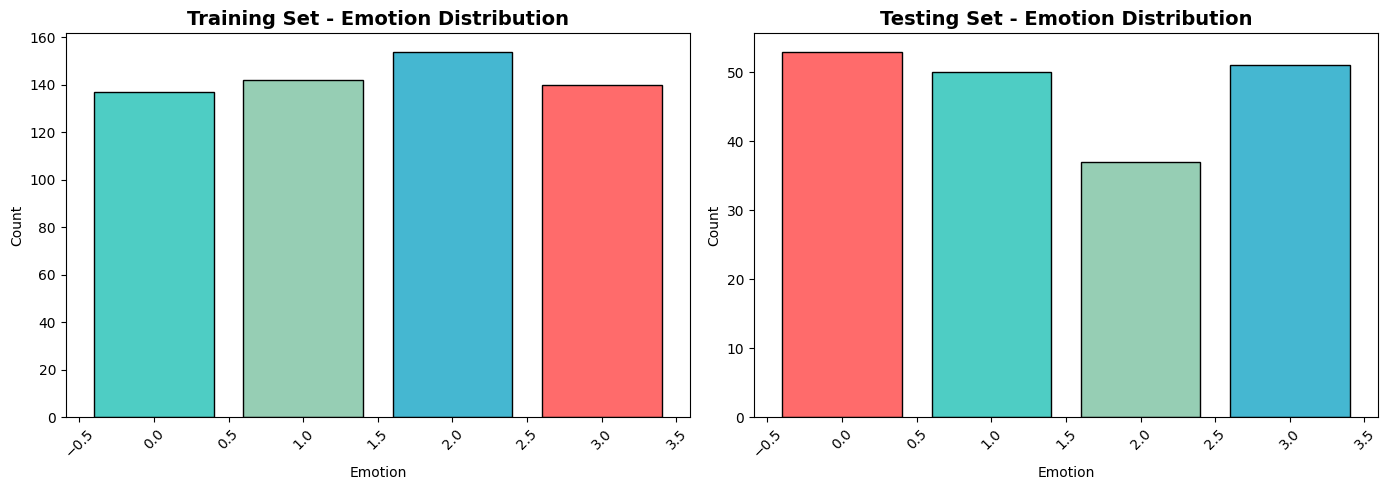

✅ Emotion distribution plotted!


In [7]:
# Cell 6: Explore and Visualize Data

# --- Plot 1: Emotion Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
from collections import Counter
train_counts = Counter(y_train)
test_counts = Counter(y_test)

axes[0].bar(
    train_counts.keys(),
    train_counts.values(),
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
    edgecolor='black'
)
axes[0].set_title('Training Set - Emotion Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Testing set distribution
axes[1].bar(
    test_counts.keys(),
    test_counts.values(),
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
    edgecolor='black'
)
axes[1].set_title('Testing Set - Emotion Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Emotion distribution plotted!")

Sample files for visualization: ['fearful', 'happy', 'disgust', 'calm']


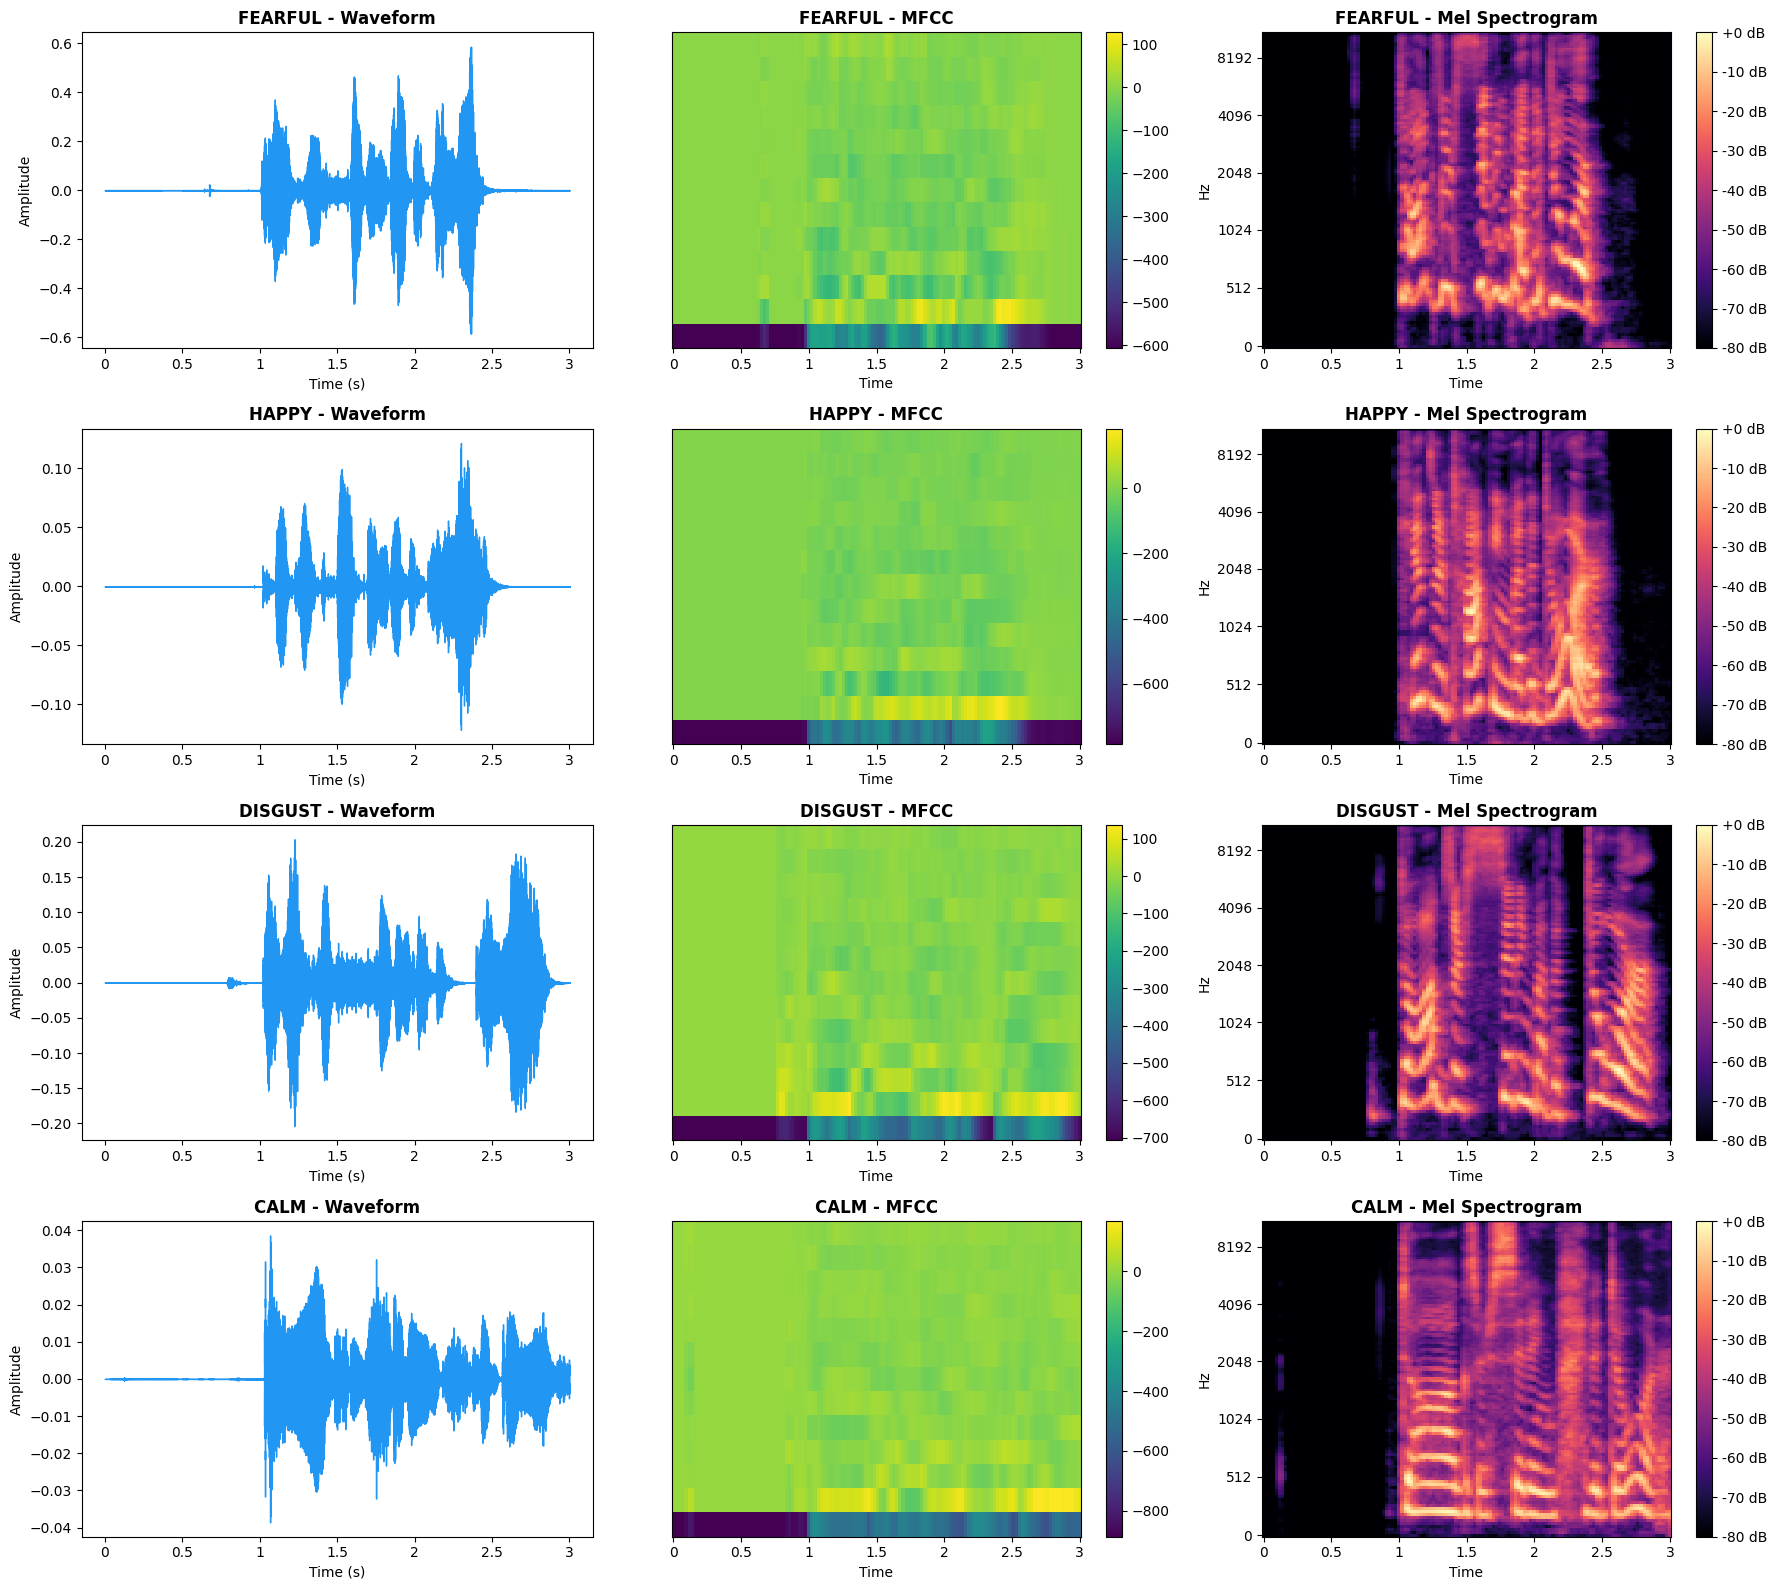

✅ Audio features visualized!


In [8]:
# Cell 7: Visualize Audio Features

# Load a sample file for visualization
sample_files = {}
for file in glob.glob("ravdess_data/**/*.wav", recursive=True)[:50]:
    emotion_code = os.path.basename(file).split("-")[2]
    emotion = emotions.get(emotion_code)
    if emotion in observed_emotions and emotion not in sample_files:
        sample_files[emotion] = file

print(f"Sample files for visualization: {list(sample_files.keys())}")

fig, axes = plt.subplots(len(sample_files), 3, figsize=(18, 4*len(sample_files)))

for idx, (emotion, file_path) in enumerate(sample_files.items()):

    # Load audio
    y_audio, sr = librosa.load(file_path, duration=3)

    # Plot 1: Waveform
    axes[idx, 0].set_title(f'{emotion.upper()} - Waveform', fontweight='bold')
    librosa.display.waveshow(y_audio, sr=sr, ax=axes[idx, 0], color='#2196F3')
    axes[idx, 0].set_xlabel('Time (s)')
    axes[idx, 0].set_ylabel('Amplitude')

    # Plot 2: MFCC
    mfccs = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=13)
    img2 = librosa.display.specshow(
        mfccs, x_axis='time', ax=axes[idx, 1], cmap='viridis'
    )
    axes[idx, 1].set_title(f'{emotion.upper()} - MFCC', fontweight='bold')
    fig.colorbar(img2, ax=axes[idx, 1])

    # Plot 3: Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y_audio, sr=sr)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img3 = librosa.display.specshow(
        mel_spec_db, x_axis='time', y_axis='mel',
        ax=axes[idx, 2], cmap='magma'
    )
    axes[idx, 2].set_title(f'{emotion.upper()} - Mel Spectrogram', fontweight='bold')
    fig.colorbar(img3, ax=axes[idx, 2], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('audio_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Audio features visualized!")

In [9]:
# Cell 8: Scale Features

# Normalize features for better MLP performance
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("✅ Features scaled successfully!")
print(f"Training features - Mean: {x_train_scaled.mean():.4f}, Std: {x_train_scaled.std():.4f}")
print(f"Testing features  - Mean: {x_test_scaled.mean():.4f}, Std: {x_test_scaled.std():.4f}")


✅ Features scaled successfully!
Training features - Mean: 0.0000, Std: 1.0000
Testing features  - Mean: 0.0324, Std: 1.4673


In [10]:
# Cell 9: Build MLP Classifier

# Initialize Multi-Layer Perceptron Classifier
model = MLPClassifier(
    hidden_layer_sizes=(300, 200, 100),  # 3 hidden layers
    activation='relu',                    # ReLU activation function
    solver='adam',                        # Adam optimizer
    alpha=0.0001,                         # L2 regularization
    batch_size='auto',                    # Auto batch size
    learning_rate='adaptive',            # Adaptive learning rate
    max_iter=500,                         # Max iterations
    random_state=42,                      # Reproducibility
    early_stopping=True,                  # Stop when validation improves
    validation_fraction=0.1,             # 10% for validation
    n_iter_no_change=20,                  # Patience for early stopping
    verbose=True                          # Show training progress
)

print("🏗️ MLP Architecture:")
print(f"  Input Layer:    {x_train.shape[1]} features")
print(f"  Hidden Layer 1: 300 neurons (ReLU)")
print(f"  Hidden Layer 2: 200 neurons (ReLU)")
print(f"  Hidden Layer 3: 100 neurons (ReLU)")
print(f"  Output Layer:   {len(label_encoder.classes_)} classes") # Use the length of encoded classes
print(f"\n⚙️  Configuration:")
print(f"  Optimizer:      Adam")
print(f"  Max Iterations: 500")
print(f"  Early Stopping: Yes (patience=20)")

🏗️ MLP Architecture:
  Input Layer:    180 features
  Hidden Layer 1: 300 neurons (ReLU)
  Hidden Layer 2: 200 neurons (ReLU)
  Hidden Layer 3: 100 neurons (ReLU)
  Output Layer:   4 classes

⚙️  Configuration:
  Optimizer:      Adam
  Max Iterations: 500
  Early Stopping: Yes (patience=20)


In [11]:
from sklearn.model_selection import GridSearchCV

# Cell 9.1: Hyperparameter Tuning with GridSearchCV

print("🧪 Starting GridSearchCV for MLPClassifier...")

# Define the parameter grid to search
param_grid = {
    'hidden_layer_sizes': [(200, 100), (300, 200, 100)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['adaptive'],
    'max_iter': [300, 500],
    'early_stopping': [True],
    'validation_fraction': [0.1],
    'n_iter_no_change': [20],
    'random_state': [42]
}

# Initialize GridSearchCV
# verbose=3 provides detailed output during fitting
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(estimator=MLPClassifier(),
                         param_grid=param_grid,
                         cv=5, # 5-fold cross-validation
                         scoring='accuracy',
                         verbose=3,
                         n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(x_train_scaled, y_train)

print("\n✅ GridSearchCV complete!")

# Get the best parameters and best model
best_params = grid_search.best_params_
best_mlp = grid_search.best_estimator_

print("\n✨ Best Hyperparameters found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\n🏆 Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

🧪 Starting GridSearchCV for MLPClassifier...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ GridSearchCV complete!

✨ Best Hyperparameters found:
  activation: relu
  alpha: 0.0001
  early_stopping: True
  hidden_layer_sizes: (300, 200, 100)
  learning_rate: adaptive
  max_iter: 300
  n_iter_no_change: 20
  random_state: 42
  solver: adam
  validation_fraction: 0.1

🏆 Best Cross-validation Accuracy: 0.7295


In [12]:
# Cell 10: Train the Model

# Train the model
best_mlp.fit(x_train_scaled, y_train)

print("\n✅ Training Complete!")
print(f"  Iterations completed: {best_mlp.n_iter_}")
print(f"  Best validation score: {best_mlp.best_validation_score_:.4f}")


✅ Training Complete!
  Iterations completed: 54
  Best validation score: 0.7759


In [13]:
# Cell 11: Make Predictions and Evaluate

# Predict on test set
y_pred = best_mlp.predict(x_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("📊 MODEL EVALUATION RESULTS")
print("="*50)
print(f"\n🎯 Overall Accuracy: {accuracy*100:.2f}%")
print(f"\n📋 Detailed Classification Report:")
print("-"*50)
# Use label_encoder.classes_ for target_names to get readable emotion names
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

📊 MODEL EVALUATION RESULTS

🎯 Overall Accuracy: 80.10%

📋 Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        calm       0.86      0.96      0.91        53
     disgust       0.84      0.82      0.83        50
     fearful       0.68      0.70      0.69        37
       happy       0.78      0.69      0.73        51

    accuracy                           0.80       191
   macro avg       0.79      0.79      0.79       191
weighted avg       0.80      0.80      0.80       191



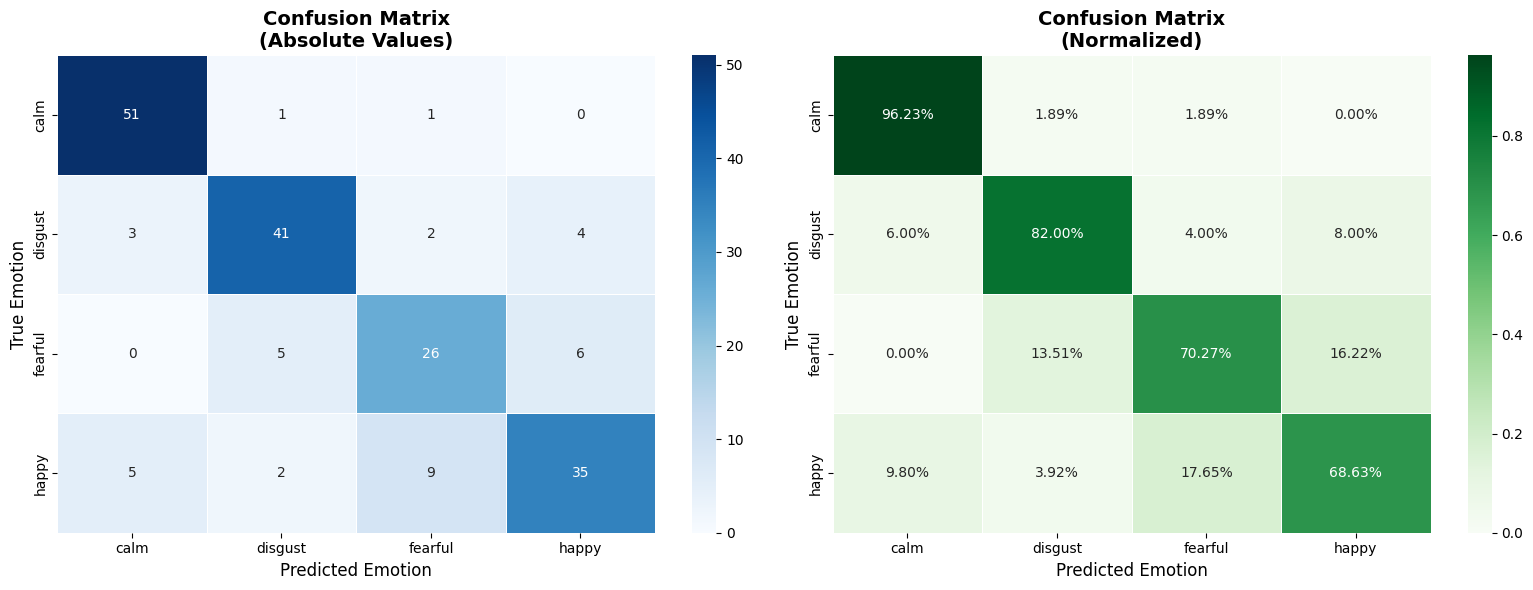

✅ Confusion matrix saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Confusion Matrix ---
# Use label_encoder.classes_ for labels, xticklabels, and yticklabels
# Fixed: Removed the 'labels' argument from confusion_matrix as y_test and y_pred are numerical.
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Confusion Matrix\n(Absolute Values)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Emotion', fontsize=12)
axes[0].set_ylabel('True Emotion', fontsize=12)

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Confusion Matrix\n(Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Emotion', fontsize=12)
axes[1].set_ylabel('True Emotion', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved!")

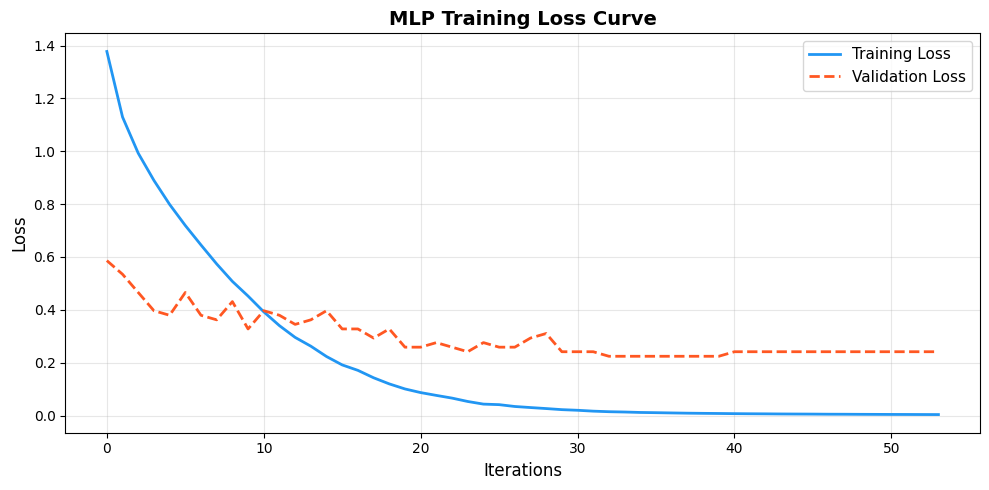

✅ Training loss curve plotted!


In [15]:
# Cell 13: Training Loss Curve

plt.figure(figsize=(10, 5))
plt.plot(best_mlp.loss_curve_, color='#2196F3', linewidth=2, label='Training Loss')
if hasattr(best_mlp, 'validation_scores_'):
    plt.plot(
        [1-s for s in best_mlp.validation_scores_],
        color='#FF5722',
        linewidth=2,
        label='Validation Loss',
        linestyle='--'
    )
plt.title('MLP Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training loss curve plotted!")

🎵 Analyzing: 03-01-06-02-02-02-04.wav

🎭 Predicted Emotion: FEARFUL

📊 Confidence Scores:
  fearful     : ███████████████████  100.0%
  happy       :                      0.0%
  disgust     :                      0.0%
  calm        :                      0.0%


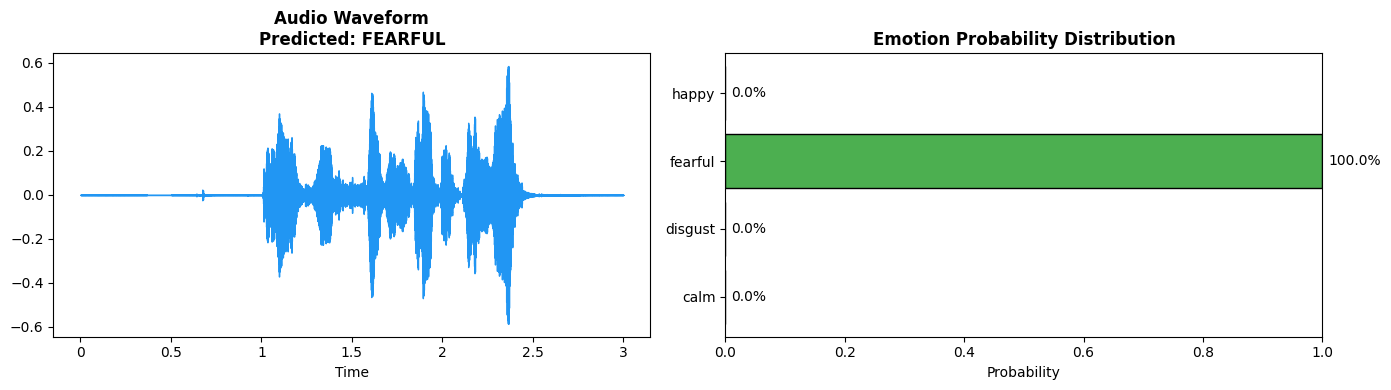

In [16]:
# Cell 14: Predict on New Audio File

def predict_emotion(audio_file_path, model, scaler, label_encoder):
    """
    Predict emotion from a new audio file

    Parameters:
    -----------
    audio_file_path : str - path to audio file
    model           : trained MLPClassifier
    scaler          : fitted StandardScaler
    label_encoder   : fitted LabelEncoder

    Returns:
    --------
    predicted emotion and probabilities
    """

    print(f"🎵 Analyzing: {os.path.basename(audio_file_path)}")

    # Extract features
    features = extract_feature(
        audio_file_path,
        mfcc=True,
        chroma=True,
        mel=True
    )

    # Reshape and scale
    features = features.reshape(1, -1)
    features_scaled = scaler.transform(features)

    # Predict numerical label
    numerical_prediction = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]

    # Inverse transform to get string emotion
    prediction = label_encoder.inverse_transform([numerical_prediction])[0]

    # Display results
    print("\n" + "="*40)
    print(f"🎭 Predicted Emotion: {prediction.upper()}")
    print("="*40)
    print("\n📊 Confidence Scores:")

    # Map numerical class probabilities to string emotion names
    emotion_probs = dict(zip(label_encoder.classes_, probabilities))
    for emotion, prob in sorted(emotion_probs.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * int(prob * 20)
        print(f"  {emotion:<12}: {bar:<20} {prob*100:.1f}%")

    return prediction, emotion_probs


# Test with a sample file
if test_files:
    sample_file = test_files[0]
    # Pass label_encoder to the prediction function
    emotion_pred, probs = predict_emotion(sample_file, best_mlp, scaler, label_encoder)

    # Visualize the audio
    y_audio, sr = librosa.load(sample_file, duration=3)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Waveform
    librosa.display.waveshow(y_audio, sr=sr, ax=axes[0], color='#2196F3')
    axes[0].set_title(f'Audio Waveform\nPredicted: {emotion_pred.upper()}', fontweight='bold')

    # Probability bar chart
    emotions_list = list(probs.keys())
    probs_list = list(probs.values())
    colors = ['#4CAF50' if e == emotion_pred else '#90CAF9' for e in emotions_list]

    axes[1].barh(emotions_list, probs_list, color=colors, edgecolor='black')
    axes[1].set_title('Emotion Probability Distribution', fontweight='bold')
    axes[1].set_xlabel('Probability')
    axes[1].set_xlim(0, 1)

    for i, (prob, emotion) in enumerate(zip(probs_list, emotions_list)):
        axes[1].text(prob + 0.01, i, f'{prob*100:.1f}%', va='center')

    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
    plt.show()

In [20]:
# Cell 15: Save the Model

import pickle
import joblib

# Save model, scaler, and label_encoder
joblib.dump(best_mlp, 'emotion_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl') # Save the label encoder

print("✅ Model saved successfully!")
print("  📁 emotion_model.pkl - Trained MLP model")
print("  📁 scaler.pkl - Feature scaler")
print("  📁 label_encoder.pkl - Label encoder") # Print for label encoder

# Download the model (for Google Colab)
from google.colab import files
files.download('emotion_model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl') # Download label encoder

✅ Model saved successfully!
  📁 emotion_model.pkl - Trained MLP model
  📁 scaler.pkl - Feature scaler
  📁 label_encoder.pkl - Label encoder


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>